In [46]:
import os

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm

sns.set_style("darkgrid")

In [2]:
print("Current Directory: ", os.getcwd())

Current Directory:  /home/alexandre/projects/qcop/notebooks


In [3]:
FILE = os.path.join("..", "data", "dataset.csv")

In [4]:
df = pd.read_csv(FILE)
df.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers
0,21156,4,./data/images/21156.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",554ae38877eb15d7bb57f6fa666db46e,2,"[3, 4]",292,339,2,2,"{""cx"": 1, ""z"": 2, ""cz"": 1}",9692,0
1,51257,8,./data/images/51257.png,"[0.489, 0.511, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",1f7f11bb1848e714347b8f7224ad0463,2,"[3, 4]",775,339,9,1,"{""cx"": 6, ""h"": 1, ""cz"": 3}",19506,3
2,39279,4,./data/images/39279.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",5c26669fded6c02feb1bdcd54f54dc04,1,[2],292,339,2,3,"{""ry"": 1, ""cz"": 2, ""z"": 1, ""x"": 1}",9009,0
3,47283,6,./data/images/47283.png,"[0.035, 0.965, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",f72d34ff0fdf443d81820b4091c38e91,2,"[0, 4]",534,339,5,2,"{""cz"": 5, ""z"": 1, ""ry"": 1}",14167,1
4,53177,4,./data/images/53177.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3e21b0d13b73e89e5e3c9f1fb09890fe,2,"[2, 3]",485,339,4,1,"{""cz"": 3, ""cx"": 1, ""z"": 1}",13048,1


In [5]:
df.result.unique()

array(['[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]',
       '[0.489, 0.511, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]',
       '[0.035, 0.965, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]',
       ...,
       '[0.165, 0.161, 0.085, 0.096, 0.099, 0.07, 0.158, 0.166, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]',
       '[0.24, 0.259, 0.219, 0.282, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]',
       '[0.017, 0.063, 0.92, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [6]:
df["resulting_labels"] = pd.factorize(df.result)[0]
df.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers,resulting_labels
0,21156,4,./data/images/21156.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",554ae38877eb15d7bb57f6fa666db46e,2,"[3, 4]",292,339,2,2,"{""cx"": 1, ""z"": 2, ""cz"": 1}",9692,0,0
1,51257,8,./data/images/51257.png,"[0.489, 0.511, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",1f7f11bb1848e714347b8f7224ad0463,2,"[3, 4]",775,339,9,1,"{""cx"": 6, ""h"": 1, ""cz"": 3}",19506,3,1
2,39279,4,./data/images/39279.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",5c26669fded6c02feb1bdcd54f54dc04,1,[2],292,339,2,3,"{""ry"": 1, ""cz"": 2, ""z"": 1, ""x"": 1}",9009,0,0
3,47283,6,./data/images/47283.png,"[0.035, 0.965, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",f72d34ff0fdf443d81820b4091c38e91,2,"[0, 4]",534,339,5,2,"{""cz"": 5, ""z"": 1, ""ry"": 1}",14167,1,2
4,53177,4,./data/images/53177.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3e21b0d13b73e89e5e3c9f1fb09890fe,2,"[2, 3]",485,339,4,1,"{""cz"": 3, ""cx"": 1, ""z"": 1}",13048,1,0


In [65]:
def plot_dist(df:pd.DataFrame) -> None:
    sns.displot(data=df, x="resulting_labels")
    plt.axvline(x=df.resulting_labels.median(), linewidth=2, color="red")
    plt.title("Distribution of results") 
    plt.show()

In [8]:
df.resulting_labels.describe()

count    35265.000000
mean      1363.781285
std       2322.425008
min          0.000000
25%          0.000000
50%        135.000000
75%       1534.000000
max       8976.000000
Name: resulting_labels, dtype: float64

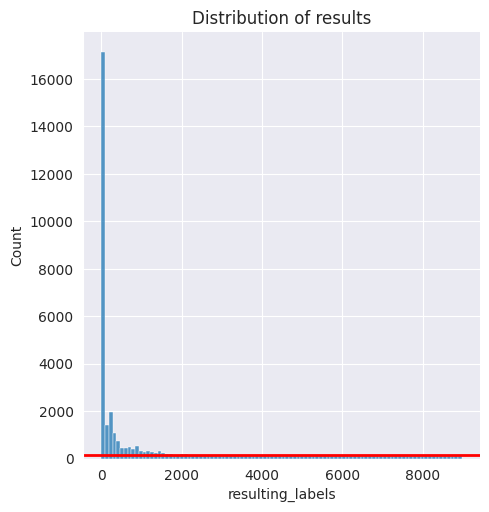

In [9]:
plot_dist(df)

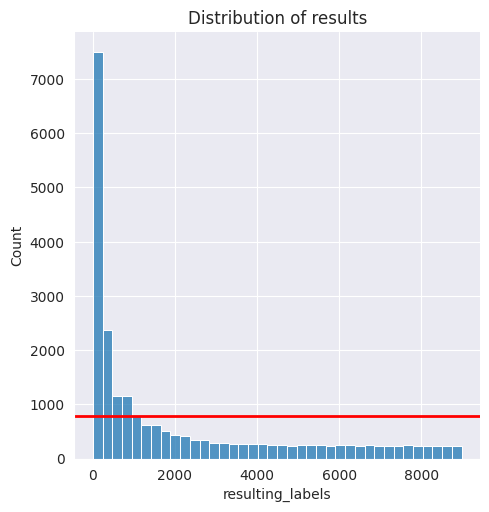

In [10]:
no_zero = df[df.resulting_labels != 0]
plot_dist(no_zero)

In [39]:
first_portion = df[df.resulting_labels.isin([0,1])]
print("First portion unique values: ", first_portion.resulting_labels.unique())
remaining = df[~df.resulting_labels.isin([0,1])]
print("is zero in remanining: ", 0 in remaining.resulting_labels.unique())
print("is one in remanining: ", 1 in remaining.resulting_labels.unique())

sample = first_portion.sample(frac=0.001)
print(sample.shape)
new_test = pd.concat([sample,remaining])

print(new_test.resulting_labels.describe())

First portion unique values:  [0 1]
is zero in remanining:  False
is one in remanining:  False
(13, 15)
count    22609.000000
mean      2127.187271
std       2605.584093
min          0.000000
25%        162.000000
50%        799.000000
75%       3548.000000
max       8976.000000
Name: resulting_labels, dtype: float64


In [56]:
new_test["count"] = 0
new_df = new_test.groupby(by="resulting_labels")["count"].count().reset_index()
new_df.head()

,resulting_labels,count
0,0,13
1,2,29
2,3,1
3,4,1
4,5,19


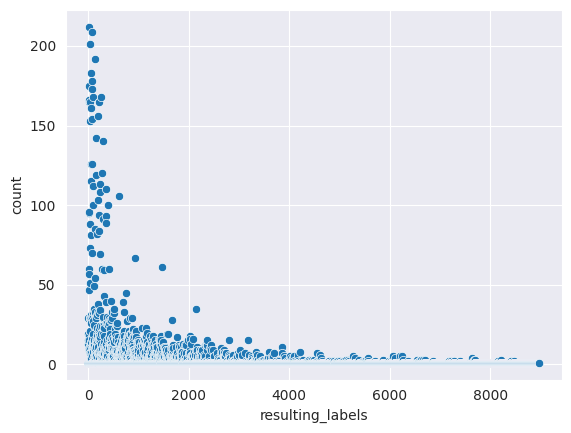

In [73]:
size = len(new_df)
sorted_vals = new_df.sort_values(by='resulting_labels')
filtered_data = sorted_vals.loc[:1*size]
sns.scatterplot(data=filtered_data, x="resulting_labels", y="count")
plt.show()

In [72]:
new_df.describe()

,resulting_labels,count
count,8976.000000,8976.000000
mean,4488.499889,2.518828
std,2591.292535,10.666705
min,0.000000,1.000000
25%,2244.750000,1.000000
50%,4488.500000,1.000000
75%,6732.250000,1.000000
max,8976.000000,212.000000


In [74]:
more_75 = new_df[new_df > new_df.quantile(0.75)]
more_75.describe()

,resulting_labels,count
count,2244.000000,909.000000
mean,7854.500000,15.997800
std,647.931324,30.368587
min,6733.000000,2.000000
25%,7293.750000,4.000000
50%,7854.500000,7.000000
75%,8415.250000,14.000000
max,8976.000000,212.000000


In [75]:
len(more_75)

8976

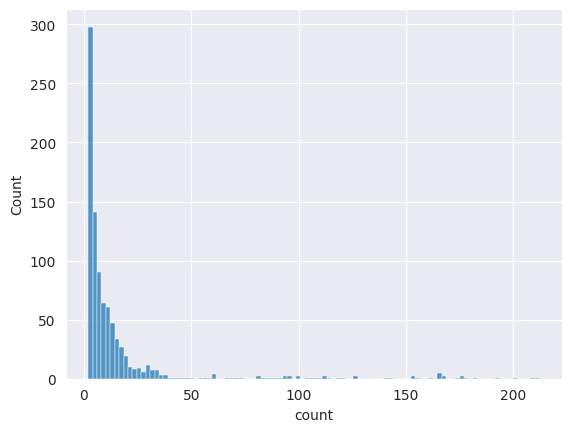

In [78]:
sns.histplot(data=more_75, x="count")
plt.show()

In [82]:
less_50 = new_df[new_df["count"] <= 50]
print(len(less_50))
less_50.describe()

8918


,resulting_labels,count
count,8918.000000,8918.000000
mean,4516.493721,1.756672
std,2576.203431,3.354733
min,0.000000,1.000000
25%,2288.250000,1.000000
50%,4517.500000,1.000000
75%,6746.750000,1.000000
max,8976.000000,49.000000


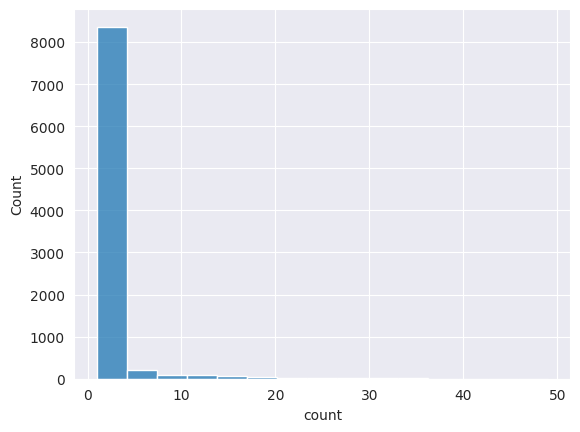

In [83]:
sns.histplot(data=less_50, x="count")
plt.show()

----

In [84]:
df["count_labels"] = 0
count_sheet = df.groupby(by="resulting_labels")['count_labels'].count().reset_index()
count_sheet.head()

,resulting_labels,count_labels
0,0,12499
1,1,170
2,2,29
3,3,1
4,4,1


In [85]:
df["count_labels"] = df["resulting_labels"].map(count_sheet.set_index("resulting_labels")["count_labels"])
df.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers,resulting_labels,count_labels
0,21156,4,./data/images/21156.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",554ae38877eb15d7bb57f6fa666db46e,2,"[3, 4]",292,339,2,2,"{""cx"": 1, ""z"": 2, ""cz"": 1}",9692,0,0,12499
1,51257,8,./data/images/51257.png,"[0.489, 0.511, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",1f7f11bb1848e714347b8f7224ad0463,2,"[3, 4]",775,339,9,1,"{""cx"": 6, ""h"": 1, ""cz"": 3}",19506,3,1,170
2,39279,4,./data/images/39279.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",5c26669fded6c02feb1bdcd54f54dc04,1,[2],292,339,2,3,"{""ry"": 1, ""cz"": 2, ""z"": 1, ""x"": 1}",9009,0,0,12499
3,47283,6,./data/images/47283.png,"[0.035, 0.965, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",f72d34ff0fdf443d81820b4091c38e91,2,"[0, 4]",534,339,5,2,"{""cz"": 5, ""z"": 1, ""ry"": 1}",14167,1,2,29
4,53177,4,./data/images/53177.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3e21b0d13b73e89e5e3c9f1fb09890fe,2,"[2, 3]",485,339,4,1,"{""cz"": 3, ""cx"": 1, ""z"": 1}",13048,1,0,12499


In [87]:
df.count_labels.describe()

count    35265.00000
mean      4461.41622
std       5955.83806
min          1.00000
25%          4.00000
50%        103.00000
75%      12499.00000
max      12499.00000
Name: count_labels, dtype: float64

In [89]:
fifty_percent_portion = df[df["count_labels"] <= df["count_labels"].quantile(0.5)]
fifty_percent_portion.count_labels.describe()

count    17675.000000
mean        16.509137
std         25.785605
min          1.000000
25%          1.000000
50%          4.000000
75%         19.000000
max        103.000000
Name: count_labels, dtype: float64

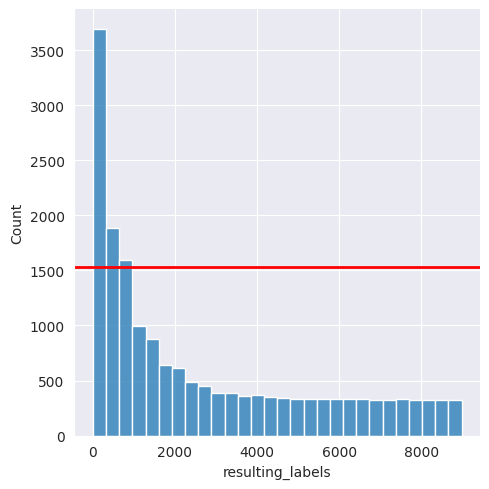

In [94]:
sns.displot(data=fifty_percent_portion, x="resulting_labels")
plt.axhline(y=fifty_percent_portion.resulting_labels.median(), linewidth=2, color="red")
plt.show()

In [98]:
fifty_percent_portion["count_labels"].std()

np.float64(25.785605198661884)

In [100]:
fifty_percent_portion[fifty_percent_portion["count_labels"] >= fifty_percent_portion["count_labels"].quantile(0.75)].count_labels.std()

np.float64(28.6519141396821)

5.126790425334983
       resulting_labels  count_labels
count      13240.000000  13240.000000
mean        3469.828172      4.379456
std         2679.878604      5.126790
min            3.000000      1.000000
25%         1098.000000      1.000000
50%         2755.500000      1.000000
75%         5720.250000      7.000000
max         8976.000000     18.000000
13240


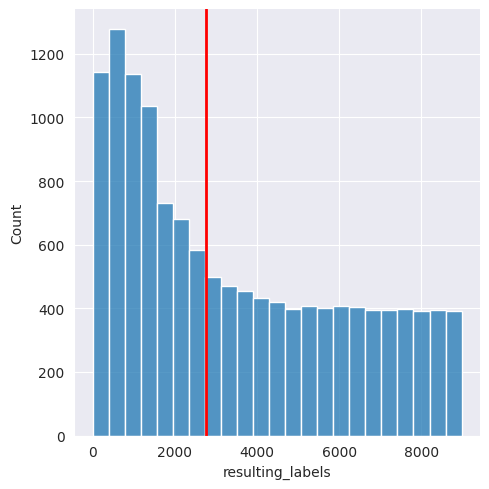

In [109]:
clean = fifty_percent_portion[fifty_percent_portion["count_labels"] < fifty_percent_portion["count_labels"].quantile(0.75)]

print(clean.count_labels.std())
print(clean[["resulting_labels", "count_labels"]].describe())
print(len(clean))

sns.displot(data=clean, x="resulting_labels")
plt.axvline(x=clean.resulting_labels.median(), linewidth=2, color="red")
plt.show()

---
## Remove portions

In [110]:
df[["resulting_labels", "count_labels"]].describe()

,resulting_labels,count_labels
count,35265.000000,35265.00000
mean,1363.781285,4461.41622
std,2322.425008,5955.83806
min,0.000000,1.00000
25%,0.000000,4.00000
50%,135.000000,103.00000
75%,1534.000000,12499.00000
max,8976.000000,12499.00000


size:  18280
std:  7.370934642689987


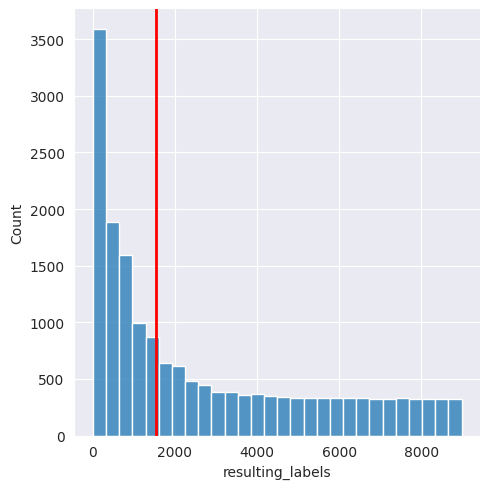

In [117]:
portion = df[df.count_labels < df.count_labels.quantile(0.5)]
remaining = df[df.count_labels >= df.count_labels.quantile(0.5)]


sample = remaining.sample(frac=0.04, random_state=42)
new_df = pd.concat([portion, sample])
new_count = new_df["resulting_labels"].value_counts()
std = new_count.std()
print("size: ", len(new_df))
print("std: ", std)
    
sns.displot(data=portion, x="resulting_labels")
plt.axvline(x=portion.resulting_labels.median(), linewidth=2, color="red")
plt.show()

In [118]:
new_df.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers,resulting_labels,count_labels
3,47283,6,./data/images/47283.png,"[0.035, 0.965, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",f72d34ff0fdf443d81820b4091c38e91,2,"[0, 4]",534,339,5,2,"{""cz"": 5, ""z"": 1, ""ry"": 1}",14167,1,2,29
5,23629,5,./data/images/23629.png,"[0.052, 0.184, 0.589, 0.175, 0.0, 0.0, 0.0, 0....",baa3a173e81c75545c3781739b4f6a44,2,"[0, 3]",485,339,3,5,"{""x"": 2, ""ry"": 3, ""cx"": 2, ""cz"": 1}",16618,2,3,1
7,24561,6,./data/images/24561.png,"[0.003, 0.003, 0.491, 0.503, 0.0, 0.0, 0.0, 0....",f0514b286e8035460fad6d4e6ed2a92b,2,"[1, 2]",534,339,3,14,"{""ry"": 4, ""id"": 4, ""z"": 2, ""h"": 1, ""x"": 3, ""cx...",17653,1,4,1
8,1061,10,./data/images/1061.png,"[0.047, 0.953, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",e03415d19aa44b2dd2c42748a6f9a85f,2,"[0, 3]",823,339,7,9,"{""h"": 3, ""cz"": 5, ""cx"": 2, ""x"": 3, ""ry"": 2, ""i...",19787,2,5,19
9,23195,9,./data/images/23195.png,"[0.101, 0.899, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",5debda3099e89240c27ee6bc6f285775,2,"[0, 3]",775,339,6,13,"{""id"": 1, ""ry"": 5, ""z"": 4, ""cz"": 4, ""x"": 2, ""c...",21706,3,6,15


In [119]:
to_save = new_df.drop(columns=["resulting_labels", "count_labels"])
to_save.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers
3,47283,6,./data/images/47283.png,"[0.035, 0.965, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",f72d34ff0fdf443d81820b4091c38e91,2,"[0, 4]",534,339,5,2,"{""cz"": 5, ""z"": 1, ""ry"": 1}",14167,1
5,23629,5,./data/images/23629.png,"[0.052, 0.184, 0.589, 0.175, 0.0, 0.0, 0.0, 0....",baa3a173e81c75545c3781739b4f6a44,2,"[0, 3]",485,339,3,5,"{""x"": 2, ""ry"": 3, ""cx"": 2, ""cz"": 1}",16618,2
7,24561,6,./data/images/24561.png,"[0.003, 0.003, 0.491, 0.503, 0.0, 0.0, 0.0, 0....",f0514b286e8035460fad6d4e6ed2a92b,2,"[1, 2]",534,339,3,14,"{""ry"": 4, ""id"": 4, ""z"": 2, ""h"": 1, ""x"": 3, ""cx...",17653,1
8,1061,10,./data/images/1061.png,"[0.047, 0.953, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",e03415d19aa44b2dd2c42748a6f9a85f,2,"[0, 3]",823,339,7,9,"{""h"": 3, ""cz"": 5, ""cx"": 2, ""x"": 3, ""ry"": 2, ""i...",19787,2
9,23195,9,./data/images/23195.png,"[0.101, 0.899, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",5debda3099e89240c27ee6bc6f285775,2,"[0, 3]",775,339,6,13,"{""id"": 1, ""ry"": 5, ""z"": 4, ""cz"": 4, ""x"": 2, ""c...",21706,3


In [120]:
#to_save.to_csv(FILE, index=False)

---

## Try Again

In [32]:
new_df = df.copy()
new_df["count"] = 0
new_df = new_df.groupby(by="resulting_labels")["count"].count().reset_index()

df["count_labels"] = 0
df["count_labels"] = df["resulting_labels"].map(new_df.set_index("resulting_labels")["count"])

new_df.head()

,resulting_labels,count
0,0,12499
1,1,170
2,2,29
3,3,1
4,4,1


In [33]:
new_df["count"].describe()

count     8977.000000
mean         3.928373
std        132.335269
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      12499.000000
Name: count, dtype: float64

In [36]:
less_75 = new_df[new_df["count"] <= new_df["count"].quantile(0.75)]
more_75 = new_df[new_df["count"] > new_df["count"].quantile(0.75)]

size_less = len(df[df["count_labels"] <= new_df["count"].quantile(0.75)])
size_more = len(df[df["count_labels"] > new_df["count"].quantile(0.75)])

print("size less: ", size_less)
print("size more: ", size_more)

more_75.describe()

size less:  8067
size more:  27198


,resulting_labels,count
count,910.000000,910.000000
mean,1617.315385,29.887912
std,1626.410770,414.944805
min,0.000000,2.000000
25%,457.250000,4.000000
50%,1119.500000,7.000000
75%,2168.250000,14.000000
max,8472.000000,12499.000000


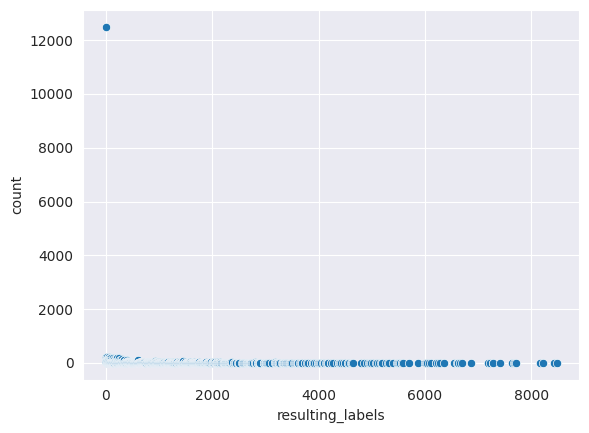

In [38]:
sns.scatterplot(data=more_75, x="resulting_labels", y="count")
plt.show()

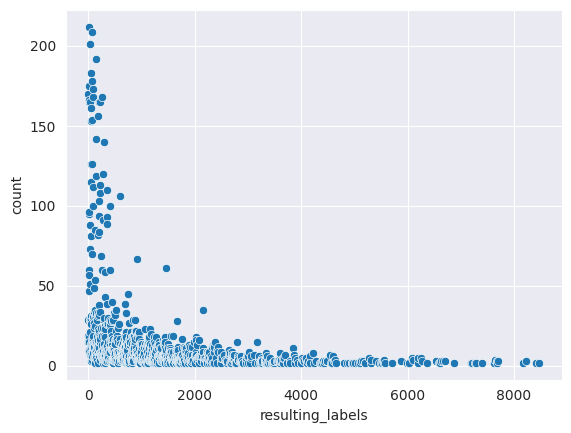

In [39]:
no_zero = more_75[more_75["resulting_labels"] != 0]
sns.scatterplot(data=no_zero, x="resulting_labels", y="count")
plt.show()

In [40]:
no_zero.describe()

,resulting_labels,count
count,909.000000,909.000000
mean,1619.094609,16.170517
std,1626.419785,30.794984
min,1.000000,2.000000
25%,458.000000,4.000000
50%,1120.000000,7.000000
75%,2169.000000,14.000000
max,8472.000000,212.000000


<= 14 portion
       resulting_labels        count
count       8767.000000  8767.000000
mean        4583.311281     1.397057
std         2545.902311     1.676931
min            3.000000     1.000000
25%         2399.500000     1.000000
50%         4593.000000     1.000000
75%         6784.500000     1.000000
max         8976.000000    14.000000
> 14 portion
       resulting_labels         count
count        210.000000    210.000000
mean         508.980952    109.604762
std          549.397512    860.530904
min            0.000000     15.000000
25%          119.000000     18.000000
50%          313.500000     26.000000
75%          765.500000     60.750000
max         3178.000000  12499.000000


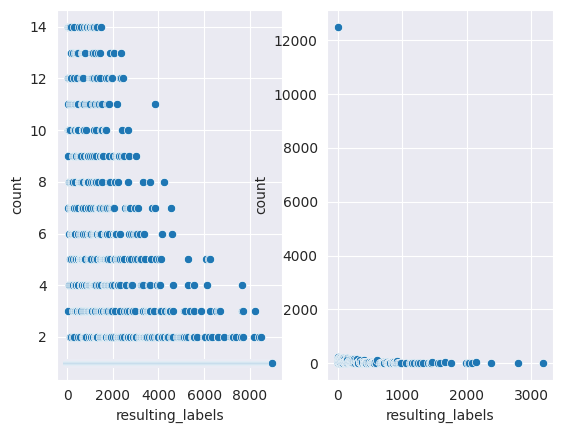

In [43]:
count_more_14 = new_df[new_df["count"] > 14]
count_less_14 = new_df[new_df["count"] <= 14]

fig,ax= plt.subplots(1,2)

print("<= 14 portion")
print(count_less_14.describe())
print("> 14 portion")
print(count_more_14.describe())

sns.scatterplot(data=count_less_14, x="resulting_labels", y="count", ax=ax[0])
sns.scatterplot(data=count_more_14, x="resulting_labels", y="count", ax=ax[1])
plt.show()

In [47]:
final_df = df[df["count_labels"] <= 14]

for label in tqdm(count_more_14.resulting_labels):
    amount = np.random.randint(2,14)
    for_label_sample = df[df["resulting_labels"] == label].sample(n=amount, random_state=42)
    final_df = pd.concat([final_df, for_label_sample])


100%|██████████████████████████████████████████████████████████████████| 210/210 [00:00<00:00, 463.68it/s]


In [52]:
new_df = final_df.copy()
new_df["count"] = 0
new_df = new_df.groupby(by="resulting_labels")["count"].count().reset_index()
new_df.describe()

,resulting_labels,count
count,8977.000000,8977.000000
mean,4488.000000,1.526568
std,2591.581017,1.930785
min,0.000000,1.000000
25%,2244.000000,1.000000
50%,4488.000000,1.000000
75%,6732.000000,1.000000
max,8976.000000,14.000000


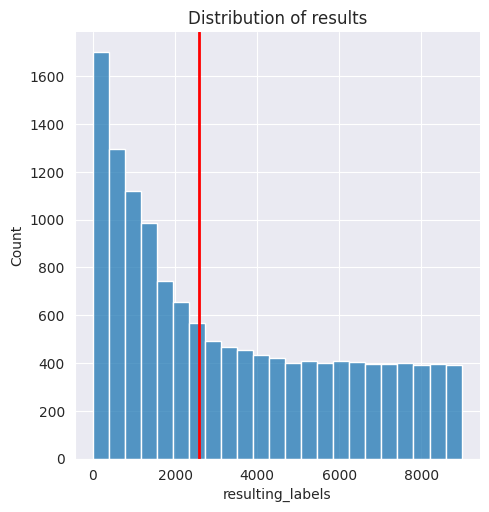

In [66]:
plot_dist(final_df)

In [67]:
to_save = final_df.drop(columns=["resulting_labels", "count_labels"])
to_save.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers
5,23629,5,./data/images/23629.png,"[0.052, 0.184, 0.589, 0.175, 0.0, 0.0, 0.0, 0....",baa3a173e81c75545c3781739b4f6a44,2,"[0, 3]",485,339,3,5,"{""x"": 2, ""ry"": 3, ""cx"": 2, ""cz"": 1}",16618,2
7,24561,6,./data/images/24561.png,"[0.003, 0.003, 0.491, 0.503, 0.0, 0.0, 0.0, 0....",f0514b286e8035460fad6d4e6ed2a92b,2,"[1, 2]",534,339,3,14,"{""ry"": 4, ""id"": 4, ""z"": 2, ""h"": 1, ""x"": 3, ""cx...",17653,1
13,28562,6,./data/images/28562.png,"[0.036, 0.475, 0.45, 0.039, 0.0, 0.0, 0.0, 0.0...",06730dac935173466c01057d659737b5,2,"[1, 4]",534,339,5,6,"{""cz"": 1, ""cx"": 4, ""h"": 3, ""ry"": 2, ""id"": 1}",17310,1
17,45133,7,./data/images/45133.png,"[0.217, 0.267, 0.304, 0.212, 0.0, 0.0, 0.0, 0....",82fc3395ed4c2deeed04b19a649f10c0,4,"[0, 2, 3, 4]",727,339,5,6,"{""cx"": 3, ""cz"": 2, ""ry"": 2, ""id"": 2, ""x"": 1, ""...",19901,2
20,8568,7,./data/images/8568.png,"[0.238, 0.262, 0.265, 0.235, 0.0, 0.0, 0.0, 0....",8246c7d6180a4ed754056eaf8929284b,2,"[2, 3]",485,339,5,6,"{""cx"": 1, ""ry"": 2, ""id"": 1, ""h"": 3, ""cz"": 4}",13429,0


In [68]:
to_save.to_csv(FILE, index=False)